# Bank Marketing Campaign Analysis

This project looks at a bank's phone marketing data to understand which groups had more term deposit subscriptions.

The main questions are:
- What percentage of contacted records ended in a subscription?
- How do age, job, balance and previous campaign results relate to the response?
- What could the bank test to improve its next campaign?

The analysis uses Python, pandas, NumPy, Matplotlib and Seaborn. It covers data cleaning, creating useful columns, EDA and conclusions.

**Running the project:** Keep this notebook in the same folder as `data/`, then run the cells from top to bottom in Jupyter. Install `pandas numpy matplotlib seaborn` if needed. For Colab, also upload `bank-full.csv` into a folder named `data`.

## About the dataset

The data is from the [UCI Bank Marketing dataset](https://archive.ics.uci.edu/dataset/222/bank+marketing). This project uses `bank-full.csv`, which contains 45,211 rows and 17 columns. The target column, `y`, tells us whether a term deposit was subscribed to.

This analysis uses the original public CSV. The dataset contains customer details, contact history and subscription outcomes.

There is no customer ID, so the number of rows may not equal the number of unique customers.

**Credits:** Moro, Rita and Cortez (2014), *Bank Marketing*, UCI, [DOI](https://doi.org/10.24432/C5K306), CC BY 4.0. Original study: Moro, Laureano and Cortez (2011), *Using Data Mining for Bank Direct Marketing*, ESM 2011, pp. 117–121. Downloaded 6 October 2026. The original data dictionary is saved in `data/bank-names.txt`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
from IPython.display import display, Markdown

SEED = 42
MIN_SEGMENT_N = 100
EXPORT_RESULTS = False
sns.set_theme(style="whitegrid", palette="deep", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13, "axes.labelsize": 11})
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## 1. Loading the data

The CSV uses a semicolon as the separator. First, load it and check a few rows. Keep a copy of the original data so the cleaning changes can be compared later.

In [2]:
data_path = Path("data") / "bank-full.csv"
raw = pd.read_csv(data_path, sep=";")
print("Rows and columns:", raw.shape)
display(raw.head())

Rows and columns: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### Important columns

| Column | Meaning |
|---|---|
| `age`, `job`, `marital`, `education` | Customer details |
| `balance` | Average yearly balance in euros; it can be negative |
| `default`, `housing`, `loan` | Default status and whether the customer has housing or personal loans |
| `contact`, `day`, `month` | Details of the last contact |
| `duration` | Last call duration in seconds |
| `campaign` | Number of contacts during this campaign, including the last one |
| `pdays` | Days since a previous campaign contact; -1 means no previous contact |
| `previous`, `poutcome` | Number of previous contacts and the previous campaign result |
| `y` | Subscription response: yes or no |

### Initial checks

Check the data types, missing values, unknown categories and duplicates before making changes.

In [3]:
profile = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing_n": raw.isna().sum(),
    "unique_n": raw.nunique(dropna=False),
    "unknown_n": raw.eq("unknown").sum(),
})
profile["unknown_pct"] = 100 * profile["unknown_n"] / len(raw)
display(profile)
print(f"Exact duplicate rows: {raw.duplicated().sum():,}")
display(raw.describe().T)

,dtype,missing_n,unique_n,unknown_n,unknown_pct
age,int64,0,77,0,0.000
job,str,0,12,288,0.637
marital,str,0,3,0,0.000
education,str,0,4,1857,4.107
default,str,0,2,0,0.000
balance,int64,0,7168,0,0.000
housing,str,0,2,0,0.000
loan,str,0,2,0,0.000
contact,str,0,3,13020,28.798
day,int64,0,31,0,0.000


Exact duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
age,"45,211.000",40.936,10.619,18.000,33.000,39.000,48.000,95.000
balance,"45,211.000","1,362.272","3,044.766","-8,019.000",72.000,448.000,"1,428.000","102,127.000"
day,"45,211.000",15.806,8.322,1.000,8.000,16.000,21.000,31.000
duration,"45,211.000",258.163,257.528,0.000,103.000,180.000,319.000,"4,918.000"
campaign,"45,211.000",2.764,3.098,1.000,1.000,2.000,3.000,63.000
pdays,"45,211.000",40.198,100.129,-1.000,-1.000,-1.000,-1.000,871.000
previous,"45,211.000",0.580,2.303,0.000,0.000,0.000,0.000,275.000


## 2. Data cleaning

There are no blank values in this CSV, but some columns contain `unknown`. These are kept as a separate category instead of guessing a value.

The cleaning steps are:
- Check numeric types and category values.
- Remove extra spaces and standardize category text.
- Rename `y` to `response` and create a 0/1 response column.
- Keep `pdays = -1` separate from actual day counts.
- Convert call duration from seconds to minutes.

Negative balances and unusually high values are not removed automatically. They can be valid. The checks below also count duplicate rows; without customer IDs, matching values alone would not prove that two rows belong to the same person.

In [4]:
numeric_cols = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
domains = {
    "job": ["admin.", "blue-collar", "entrepreneur", "housemaid", "management", "retired",
            "self-employed", "services", "student", "technician", "unemployed", "unknown"],
    "marital": ["divorced", "married", "single"],
    "education": ["primary", "secondary", "tertiary", "unknown"],
    "default": ["yes", "no"], "housing": ["yes", "no"], "loan": ["yes", "no"],
    "contact": ["cellular", "telephone", "unknown"],
    "month": ["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"],
    "poutcome": ["failure", "other", "success", "unknown"], "y": ["yes", "no"],
}
df = raw.copy(deep=True)
df.columns = df.columns.str.strip().str.lower()
assert set(df.columns) == set(numeric_cols) | set(domains)
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="raise")
assert df.notna().all().all(), "Unexpected literal missing value: review before analysis"
assert np.isfinite(df[numeric_cols].to_numpy()).all()
category_changes = 0
for col, allowed in domains.items():
    normalized = df[col].astype("string").str.strip().str.lower()
    category_changes += int(normalized.ne(df[col]).sum())
    assert normalized.isin(allowed).all(), f"Unexpected category in {col}"
    df[col] = normalized.astype("category")
assert df["age"].between(18, 120).all()
assert df["day"].between(1, 31).all()
assert df["duration"].ge(0).all() and df["campaign"].ge(1).all()
assert df["pdays"].ge(-1).all() and df["previous"].ge(0).all()
assert df[numeric_cols].eq(np.floor(df[numeric_cols])).all().all()

print("Data types and category checks passed.")

Data types and category checks passed.


### Fixing column names and units

Keep `raw` unchanged and work with `df`. The new days-since-contact column leaves never-contacted records empty instead of treating -1 as a real number of days.

In [5]:
df = df.rename(columns={"y": "response"})
df["response_flag"] = df["response"].astype("string").map({"no": 0, "yes": 1}).astype("int8")
df["previously_contacted"] = df["pdays"].ne(-1)
df["days_since_previous_contact"] = df["pdays"].where(df["previously_contacted"])
df["duration_minutes"] = df["duration"] / 60
df["unknown_field_count"] = df[[col for col in domains if col != "y"]].eq("unknown").sum(axis=1)

audit = pd.DataFrame([
    ("Source records", len(raw), "Keep unmodified source separately"),
    ("Literal missing cells", int(raw.isna().sum().sum()), "No blanket imputation"),
    ("Category values normalized", category_changes, "Strip and lowercase"),
    ("Unknown category cells", int(raw.eq("unknown").sum().sum()), "Retain explicitly"),
    ("Never-contacted sentinels", int(df["pdays"].eq(-1).sum()), "Flag + nullable elapsed days"),
    ("Exact duplicate rows", int(raw.duplicated().sum()), "Retain; no customer ID"),
    ("Negative balances", int(df["balance"].lt(0).sum()), "Retain valid balance values"),
    ("Zero-duration calls", int(df["duration"].eq(0).sum()), "Retain and disclose"),
    ("Rows removed", len(raw) - len(df), "No unsupported row deletion"),
], columns=["check", "count", "decision"])
display(audit)
assert len(df) == len(raw)
assert df["response_flag"].isin([0, 1]).all()
assert df["days_since_previous_contact"].isna().equals(~df["previously_contacted"])

,check,count,decision
0,Source records,45211,Keep unmodified source separately
1,Literal missing cells,0,No blanket imputation
2,Category values normalized,0,Strip and lowercase
3,Unknown category cells,52124,Retain explicitly
4,Never-contacted sentinels,36954,Flag + nullable elapsed days
5,Exact duplicate rows,0,Retain; no customer ID
6,Negative balances,3766,Retain valid balance values
7,Zero-duration calls,3,Retain and disclose
8,Rows removed,0,No unsupported row deletion


## 3. Creating useful columns

Age groups and balance groups make the comparisons easier to read. `pd.cut` creates age and contact-count bands, while `np.select` creates balance groups.

For example, age 30 belongs to 30–39, not Under 30. A small month lookup table is joined to keep months in calendar order. This is just a display order because the data has no year column.

Balance is very skewed, so a signed log column is used for plotting. It reduces the effect of large values while keeping negative balances visible.

In [6]:
df["age_group"] = pd.cut(df["age"], bins=[0, 30, 40, 50, 60, np.inf],
                         labels=["Under 30", "30–39", "40–49", "50–59", "60+"], right=False)
df["campaign_band"] = pd.cut(df["campaign"], bins=[0, 1, 2, 3, 5, 10, np.inf],
                             labels=["1", "2", "3", "4–5", "6–10", "11+"])
df["balance_band"] = pd.Categorical(np.select(
    [df["balance"].lt(0), df["balance"].eq(0), df["balance"].le(1000), df["balance"].le(5000)],
    ["Negative", "Zero", "1–1,000", "1,001–5,000"], default="Above 5,000"),
    categories=["Negative", "Zero", "1–1,000", "1,001–5,000", "Above 5,000"], ordered=True)
df["signed_log_balance"] = np.sign(df["balance"]) * np.log1p(np.abs(df["balance"]))
month_lookup = pd.DataFrame({"month": domains["month"], "month_order": np.arange(1, 13)})
df = df.merge(month_lookup, on="month", how="left", validate="many_to_one", indicator=True)
assert df["_merge"].eq("both").all() and len(df) == len(raw)
df = df.drop(columns="_merge")
df["month"] = pd.Categorical(df["month"], categories=domains["month"], ordered=True)
assert df[["age_group", "campaign_band", "balance_band", "month_order"]].notna().all().all()
display(df[["age", "age_group", "balance", "balance_band", "campaign", "campaign_band",
            "pdays", "days_since_previous_contact", "duration_minutes", "response_flag"]].head())

,age,age_group,balance,balance_band,campaign,campaign_band,pdays,days_since_previous_contact,duration_minutes,response_flag
0,58,50–59,2143,"1,001–5,000",1,1,-1,NaN,4.350,0
1,44,40–49,29,"1–1,000",1,1,-1,NaN,2.517,0
2,33,30–39,2,"1–1,000",1,1,-1,NaN,1.267,0
3,47,40–49,1506,"1,001–5,000",1,1,-1,NaN,1.533,0
4,33,30–39,1,"1–1,000",1,1,-1,NaN,3.300,0


## 4. Overall response rate

**Response rate = number of yes responses / number of records.** Since `response_flag` is 0 or 1, its mean gives this rate.

The helper function below calculates the same summary for each group. Counts are included because a high rate in a small group can be misleading. The rate ratio compares a group with the overall rate; it is not a measured improvement from changing the campaign.

The charts also show 95% Wilson confidence intervals. These give a rough idea of uncertainty around each rate, assuming independent records. Repeated customers and the way the bank selected contacts can affect this assumption. Groups under 100 rows are flagged, and small heatmap cells are hidden. The intervals are not a significance test across all groups.

In [7]:
baseline = df["response_flag"].mean()
def segment_summary(data, group):
    out = data.groupby(group, observed=True)["response_flag"].agg(records="size", subscriptions="sum")
    n = out["records"].to_numpy(dtype=float)
    p = out["subscriptions"].to_numpy(dtype=float) / n
    # Wilson interval for a proportion; 1.96 is the usual 95% z value.
    z = 1.959963984540054

    denom = 1 + z*z/n
    center = (p + z*z/(2*n)) / denom
    half = z * np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / denom
    out["rate"] = p
    out["ci_low"], out["ci_high"] = center - half, center + half
    out["record_share"] = n / len(data)
    out["difference_pp"] = 100 * (p - data["response_flag"].mean())
    out["observed_rate_ratio"] = p / data["response_flag"].mean()
    out["small_segment"] = n < MIN_SEGMENT_N
    return out

kpis = pd.Series({"Campaign records": len(df), "Subscriptions": int(df["response_flag"].sum()),
                  "Subscription rate (%)": 100*baseline,
                  "Median age (years)": df["age"].median(),
                  "Median balance (EUR)": df["balance"].median(),
                  "Previously contacted (%)": 100*df["previously_contacted"].mean()}, name="value")
display(kpis.to_frame())
display(Markdown(f"**Baseline:** {int(df.response_flag.sum()):,} subscriptions from {len(df):,} records "
                 f"(**{baseline:.2%}**). The remaining {1-baseline:.2%} did not subscribe. "
                 "The responses are imbalanced, so the group comparisons should include counts as well as rates."))

,value
Campaign records,"45,211.000"
Subscriptions,"5,289.000"
Subscription rate (%),11.698
Median age (years),39.000
Median balance (EUR),448.000
Previously contacted (%),18.263


**Baseline:** 5,289 subscriptions from 45,211 records (**11.70%**). The remaining 88.30% did not subscribe. The responses are imbalanced, so the group comparisons should include counts as well as rates.

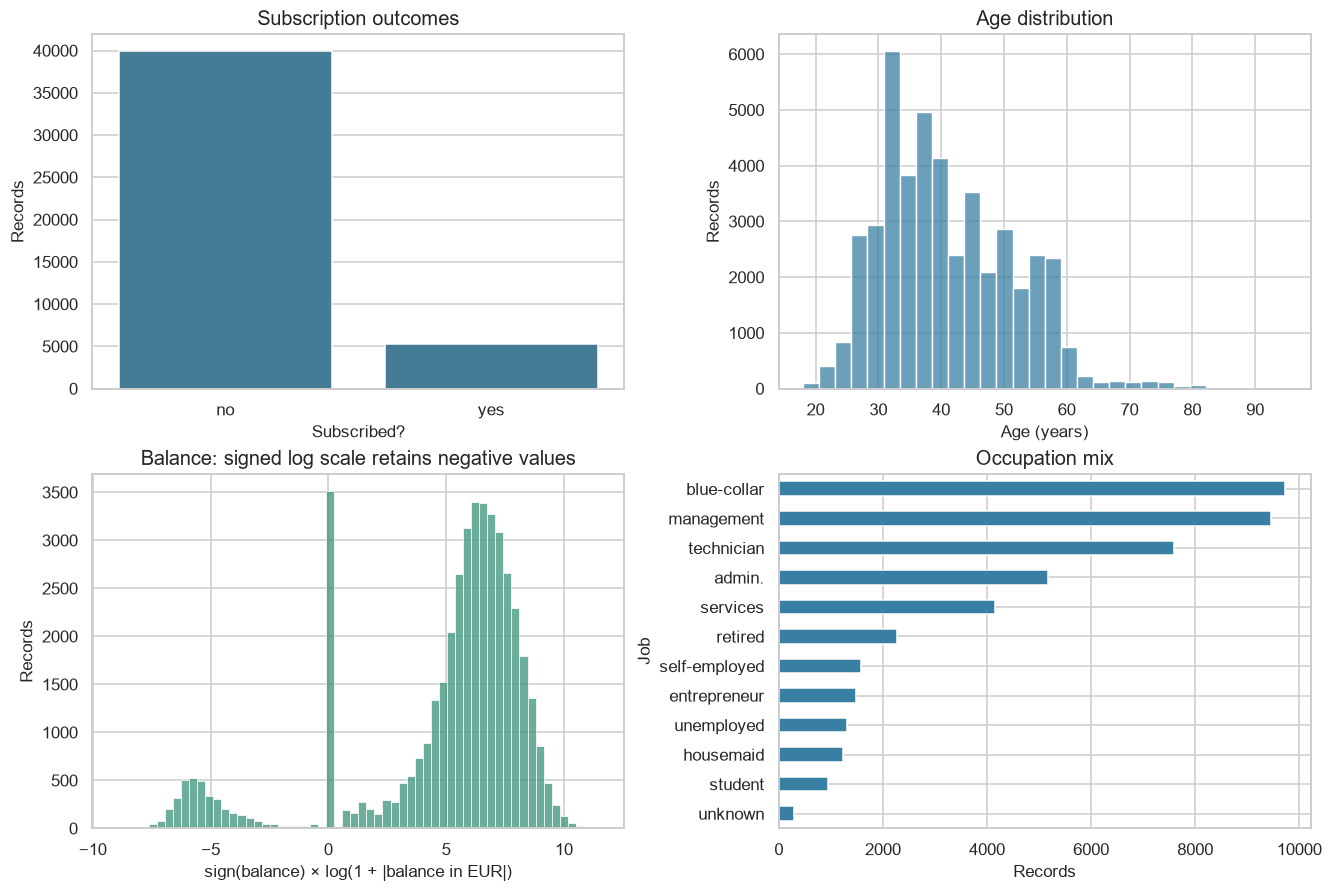

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
sns.countplot(data=df, x="response", order=["no", "yes"], color="#397FA3", ax=axes[0, 0])
axes[0, 0].set(title="Subscription outcomes", xlabel="Subscribed?", ylabel="Records")
sns.histplot(data=df, x="age", bins=30, color="#397FA3", ax=axes[0, 1])
axes[0, 1].set(title="Age distribution", xlabel="Age (years)", ylabel="Records")
sns.histplot(data=df, x="signed_log_balance", bins=60, color="#3B927B", ax=axes[1, 0])
axes[1, 0].set(title="Balance: signed log scale retains negative values", xlabel="sign(balance) × log(1 + |balance in EUR|)", ylabel="Records")
df["job"].value_counts().sort_values().plot.barh(ax=axes[1, 1], color="#397FA3")
axes[1, 1].set(title="Occupation mix", xlabel="Records", ylabel="Job")
plt.show()

### Observations

Most responses are no. The balance distribution also has a long tail, which is why comparing medians as well as means is useful. The job chart shows which occupations make up most of this dataset.

## 5. Comparing customer groups

Next, compare response rates across jobs, age groups, education and loan status. Each label includes the number of records in that group.

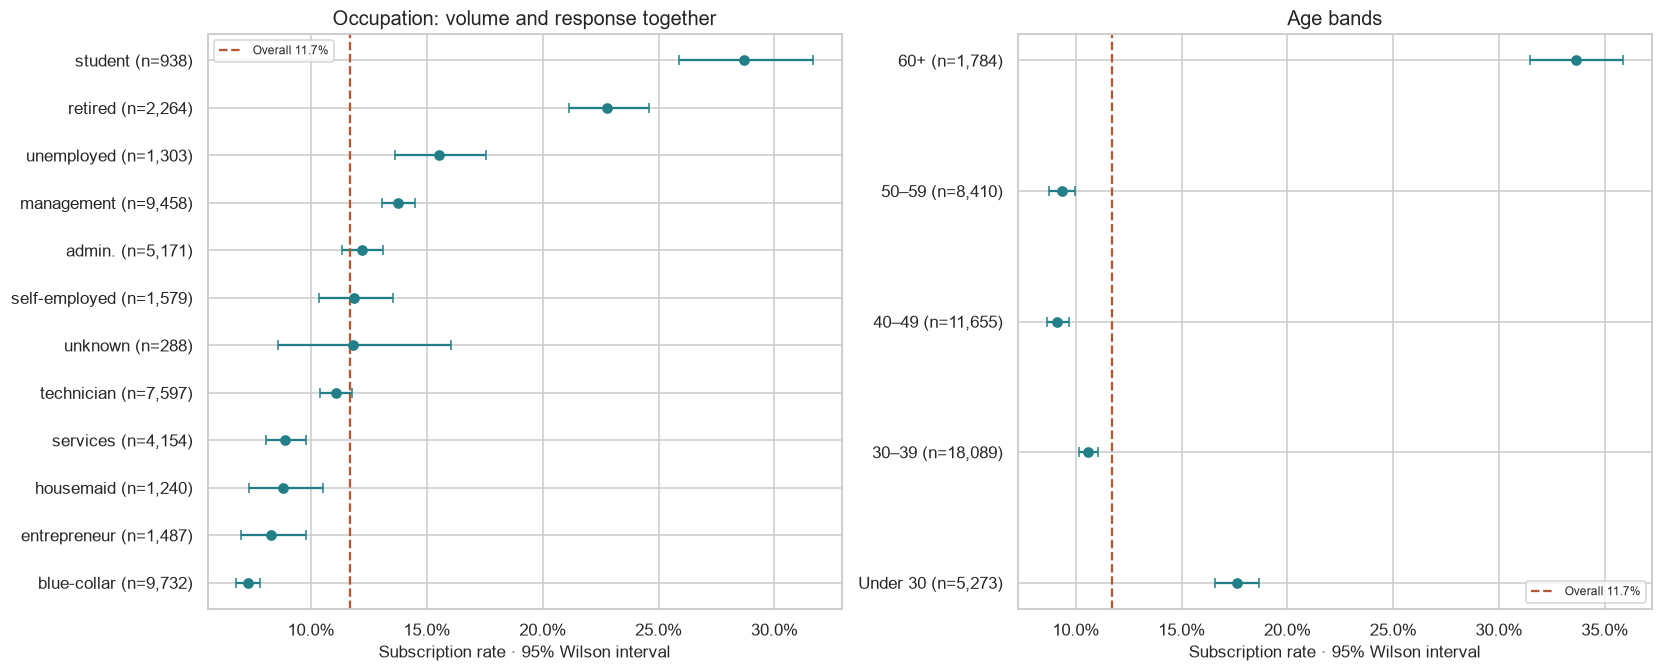

,records,subscriptions,rate,ci_low,ci_high,record_share,difference_pp,observed_rate_ratio,small_segment
job,,,,,,,,,
student,938,269,0.287,0.259,0.317,0.021,16.980,2.451,False
retired,2264,516,0.228,0.211,0.246,0.050,11.093,1.948,False
unemployed,1303,202,0.155,0.136,0.176,0.029,3.804,1.325,False
management,9458,1301,0.138,0.131,0.145,0.209,2.057,1.176,False
admin.,5171,631,0.122,0.113,0.131,0.114,0.504,1.043,False
self-employed,1579,187,0.118,0.103,0.135,0.035,0.144,1.012,False
unknown,288,34,0.118,0.086,0.160,0.006,0.107,1.009,False
technician,7597,840,0.111,0.104,0.118,0.168,-0.641,0.945,False
services,4154,369,0.089,0.081,0.098,0.092,-2.815,0.759,False


In [9]:
segments = {col: segment_summary(df, col) for col in
            ["job", "education", "marital", "age_group", "housing", "loan", "balance_band",
             "contact", "poutcome", "previously_contacted", "campaign_band", "month"]}
# Reuse this function to keep the group charts consistent.
def plot_rates(table, ax, title, sort=True):
    t = table.sort_values("rate") if sort else table
    positions = np.arange(len(t))
    errors = np.vstack([t["rate"]-t["ci_low"], t["ci_high"]-t["rate"]])
    ax.errorbar(t["rate"], positions, xerr=errors, fmt="o", color="#237F87", capsize=3)
    ax.set_yticks(positions, [f"{v} (n={n:,})" for v,n in zip(t.index, t["records"])])
    ax.axvline(baseline, color="#B35835", linestyle="--", label=f"Overall {baseline:.1%}")
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.set(title=title, xlabel="Subscription rate · 95% Wilson interval", ylabel="")
    ax.legend(loc="best", fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)
plot_rates(segments["job"], axes[0], "Occupation: volume and response together")
plot_rates(segments["age_group"], axes[1], "Age bands", sort=False)
plt.show()
display(segments["job"].sort_values("rate", ascending=False))

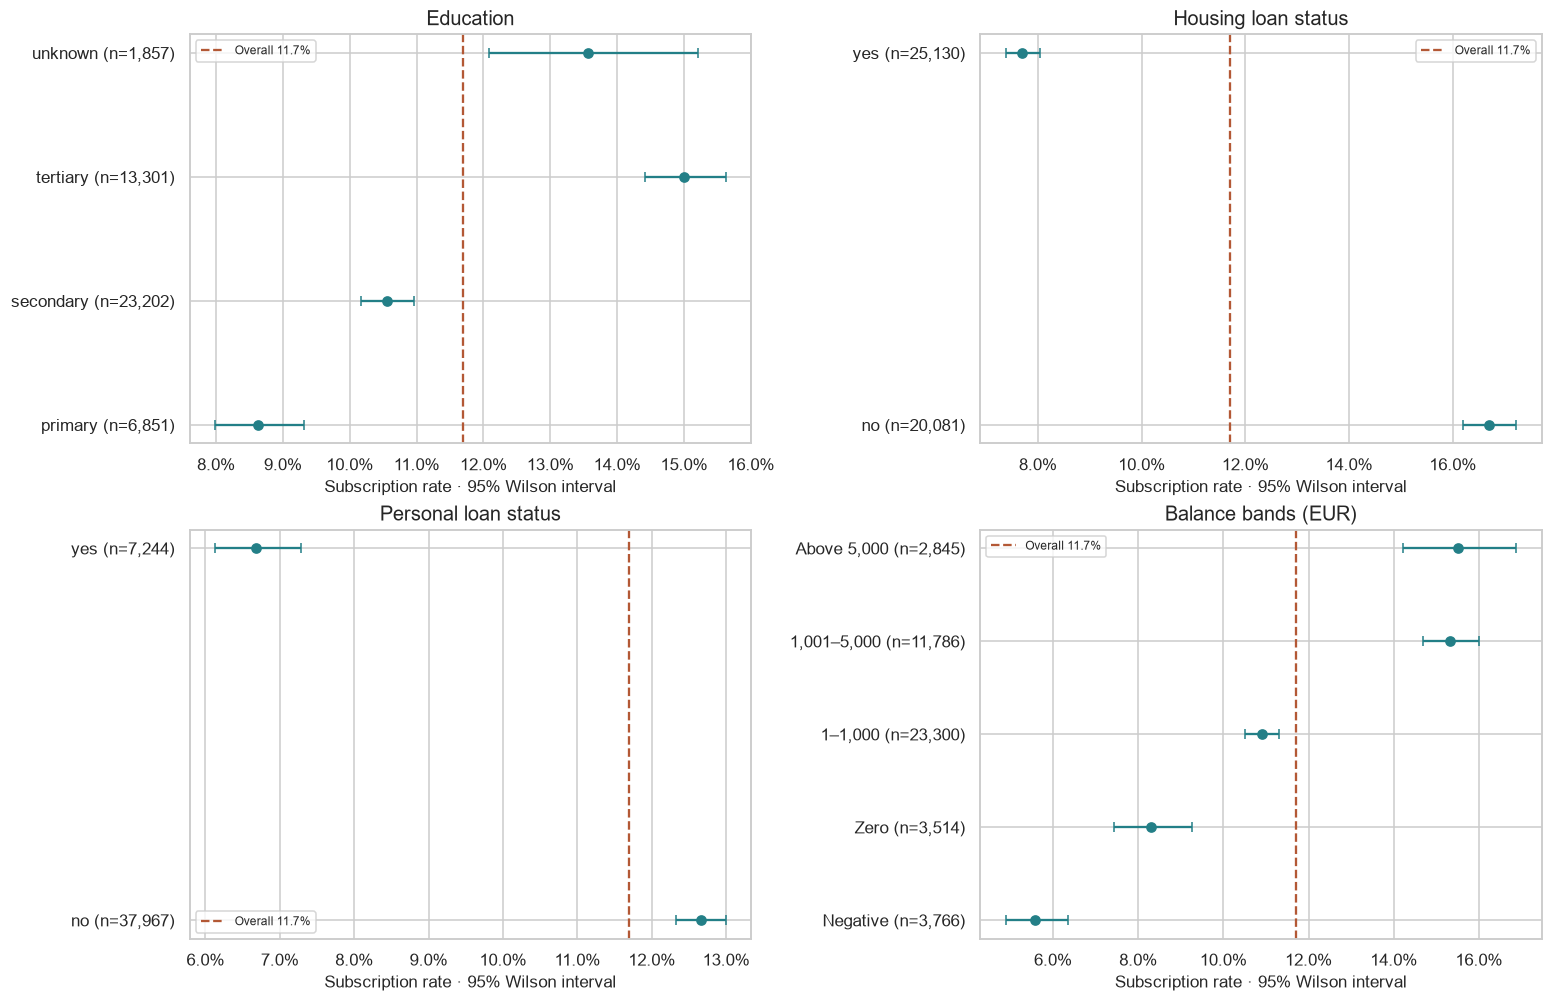

,records,mean,median,p75
response,,,,
no,39922,"1,303.715",417.000,"1,345.000"
yes,5289,"1,804.268",733.000,"2,159.000"


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
for ax, key, title in zip(axes.ravel(), ["education", "housing", "loan", "balance_band"],
                          ["Education", "Housing loan status", "Personal loan status", "Balance bands (EUR)"]):
    plot_rates(segments[key], ax, title, sort=False)
plt.show()
balance_by_response = df.groupby("response", observed=True)["balance"].agg(
    records="size", mean="mean", median="median", p75=lambda x: np.quantile(x, .75))
display(balance_by_response)

The mean balance can be affected by a few large values, so the table includes the median and 75th percentile too. These group differences describe the dataset; they do not show that a person's job or age causes a subscription.

## 6. Previous campaigns and contact details

Previous campaign results may be useful when planning a new campaign. The final number of calls needs more care: a customer who has not subscribed may simply have received more follow-up calls.

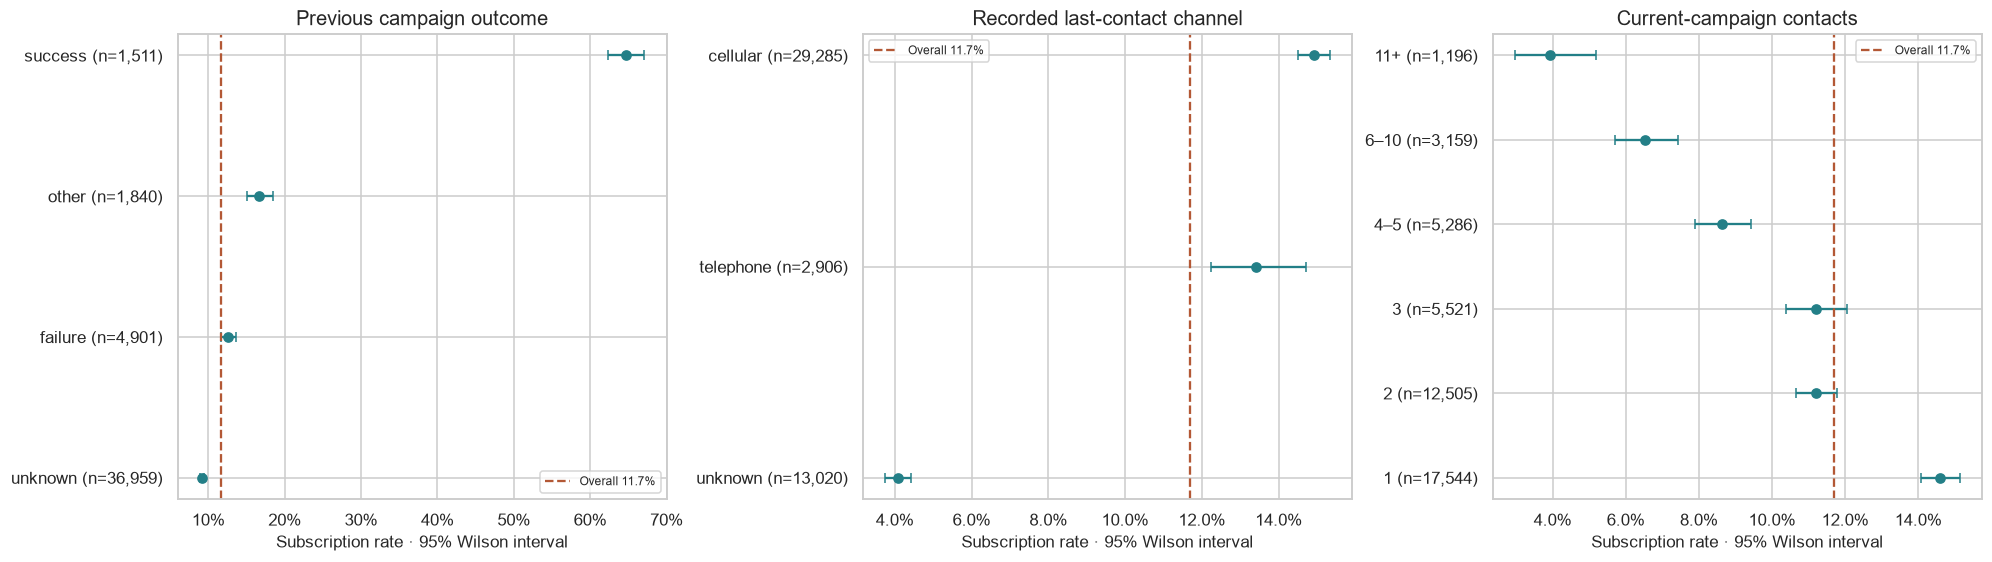

,records,subscriptions,rate,ci_low,ci_high,record_share,difference_pp,observed_rate_ratio,small_segment
poutcome,,,,,,,,,
success,1511,978,0.647,0.623,0.671,0.033,53.027,5.533,False
other,1840,307,0.167,0.151,0.185,0.041,4.986,1.426,False
failure,4901,618,0.126,0.117,0.136,0.108,0.911,1.078,False
unknown,36959,3386,0.092,0.089,0.095,0.817,-2.537,0.783,False


,records,subscriptions,rate,ci_low,ci_high,record_share,difference_pp,observed_rate_ratio,small_segment
campaign_band,,,,,,,,,
1,17544,2561,0.146,0.141,0.151,0.388,2.899,1.248,False
2,12505,1401,0.112,0.107,0.118,0.277,-0.495,0.958,False
3,5521,618,0.112,0.104,0.121,0.122,-0.505,0.957,False
4–5,5286,456,0.086,0.079,0.094,0.117,-3.072,0.737,False
6–10,3159,206,0.065,0.057,0.074,0.070,-5.177,0.557,False
11+,1196,47,0.039,0.030,0.052,0.026,-7.769,0.336,False


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
plot_rates(segments["poutcome"], axes[0], "Previous campaign outcome")
plot_rates(segments["contact"], axes[1], "Recorded last-contact channel")
plot_rates(segments["campaign_band"], axes[2], "Current-campaign contacts", sort=False)
plt.show()
display(segments["poutcome"].sort_values("rate", ascending=False))
display(segments["campaign_band"])

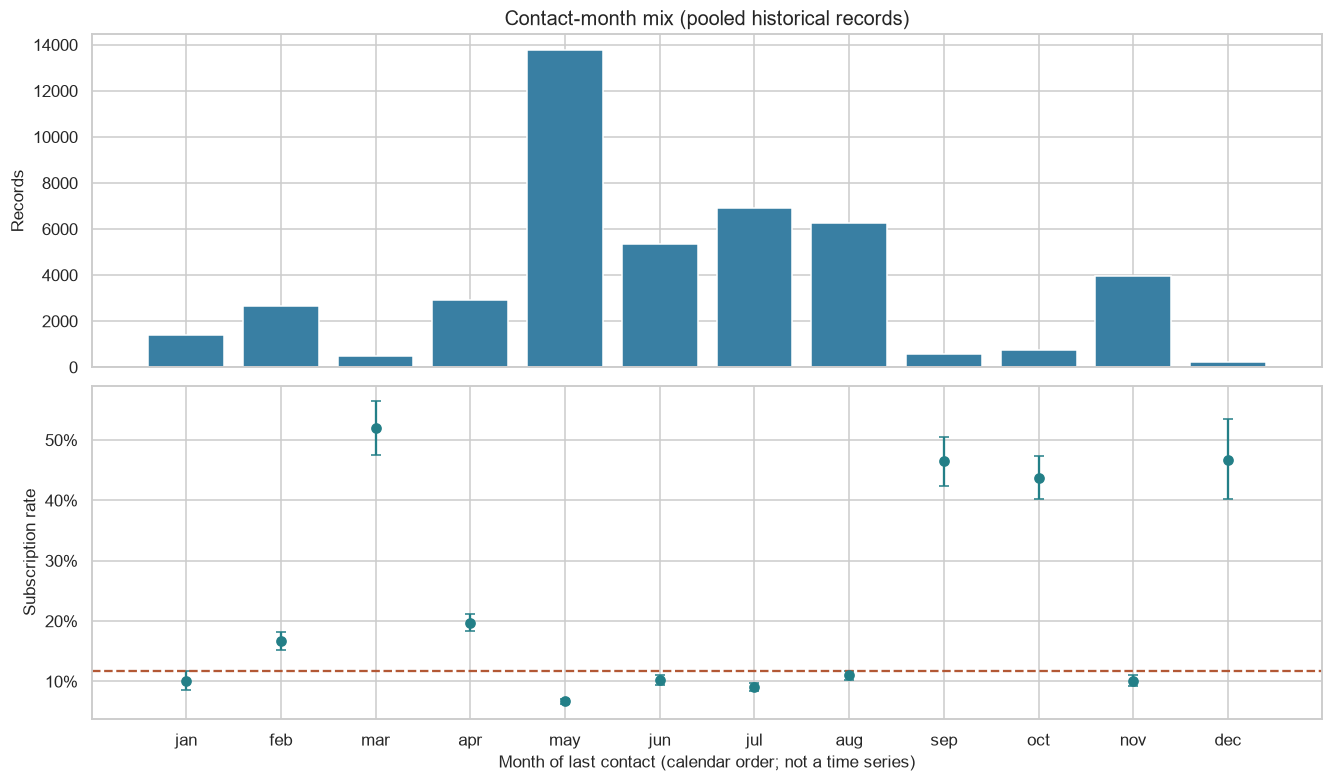

,records,subscriptions,rate,ci_low,ci_high,record_share,difference_pp,observed_rate_ratio,small_segment
month,,,,,,,,,
jan,1403,142,0.101,0.087,0.118,0.031,-1.577,0.865,False
feb,2649,441,0.166,0.153,0.181,0.059,4.949,1.423,False
mar,477,248,0.520,0.475,0.564,0.011,40.293,4.444,False
apr,2932,577,0.197,0.183,0.212,0.065,7.981,1.682,False
may,13766,925,0.067,0.063,0.071,0.304,-4.979,0.574,False
jun,5341,546,0.102,0.094,0.111,0.118,-1.476,0.874,False
jul,6895,627,0.091,0.084,0.098,0.153,-2.605,0.777,False
aug,6247,688,0.110,0.103,0.118,0.138,-0.685,0.941,False
sep,579,269,0.465,0.424,0.505,0.013,34.761,3.971,False


In [12]:
months = segments["month"].reindex(domains["month"])
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True)
axes[0].bar(months.index.astype(str), months["records"], color="#397FA3")
axes[0].set(title="Contact-month mix (pooled historical records)", ylabel="Records")
axes[1].errorbar(months.index.astype(str), months["rate"],
                 yerr=np.vstack([months["rate"]-months["ci_low"], months["ci_high"]-months["rate"]]),
                 fmt="o", capsize=3, color="#237F87")
axes[1].axhline(baseline, linestyle="--", color="#B35835")
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].set(xlabel="Month of last contact (calendar order; not a time series)", ylabel="Subscription rate")
plt.show()
display(months)

The monthly chart combines records from different periods. It does not prove that a particular month is always better for marketing, since the customers and campaigns may be different.

## 7. Looking at multiple columns together

The heatmap compares education and previous campaign results together. It shows the response rate and number of records in each group. Cells with fewer than 100 records are left blank to avoid drawing conclusions from very small groups.

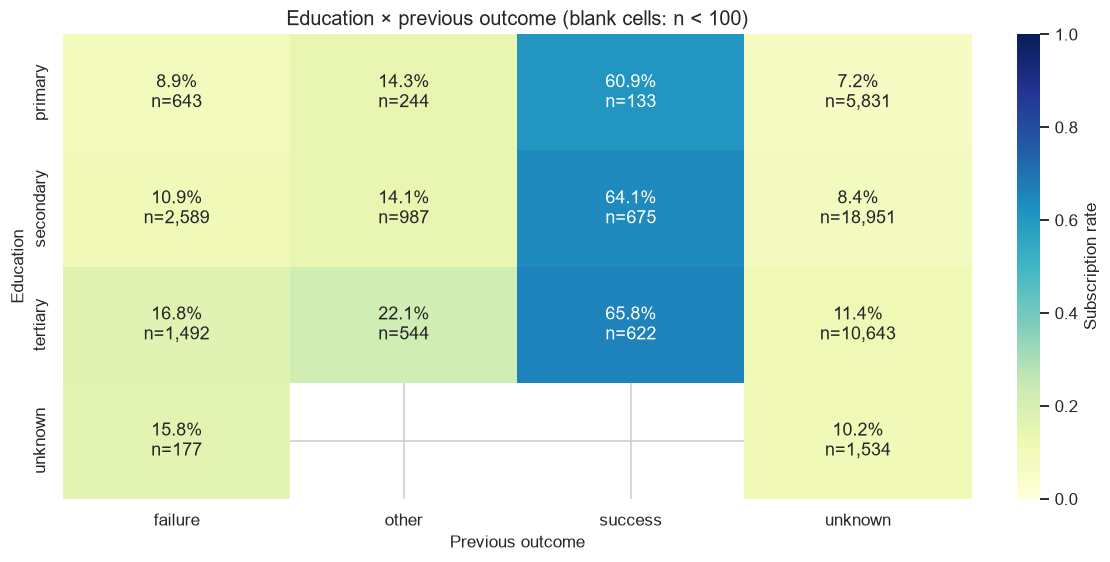

,education,poutcome,records,rate
0,primary,failure,643,0.089
1,primary,other,244,0.143
2,primary,success,133,0.609
3,primary,unknown,5831,0.072
4,secondary,failure,2589,0.109
5,secondary,other,987,0.141
6,secondary,success,675,0.641
7,secondary,unknown,18951,0.084
8,tertiary,failure,1492,0.168
9,tertiary,other,544,0.221


,education,poutcome,metric,value
0,primary,failure,records,643.000
1,primary,other,records,244.000
2,primary,success,records,133.000
3,primary,unknown,records,"5,831.000"
4,secondary,failure,records,"2,589.000"
5,secondary,other,records,987.000
6,secondary,success,records,675.000
7,secondary,unknown,records,"18,951.000"


In [13]:
joint = df.groupby(["education", "poutcome"], observed=True)["response_flag"].agg(records="size", rate="mean")
joint_rate = joint["rate"].unstack("poutcome")
joint_n = joint["records"].unstack("poutcome").reindex_like(joint_rate)
labels = pd.DataFrame("", index=joint_rate.index, columns=joint_rate.columns)
for row in labels.index:
    for col in labels.columns:
        n = joint_n.loc[row, col]
        if pd.notna(n) and n >= MIN_SEGMENT_N:
            labels.loc[row, col] = f"{joint_rate.loc[row, col]:.1%}\nn={int(n):,}"
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
sns.heatmap(joint_rate, mask=joint_n.lt(MIN_SEGMENT_N) | joint_n.isna(), annot=labels, fmt="",
            cmap="YlGnBu", vmin=0, vmax=1, ax=ax, cbar_kws={"label": "Subscription rate"})
ax.set(title="Education × previous outcome (blank cells: n < 100)", xlabel="Previous outcome", ylabel="Education")
plt.show()
display(joint.reset_index())

joint_tidy = joint.reset_index().melt(id_vars=["education", "poutcome"],
                                     value_vars=["records", "rate"], var_name="metric", value_name="value")
display(joint_tidy.head(8))

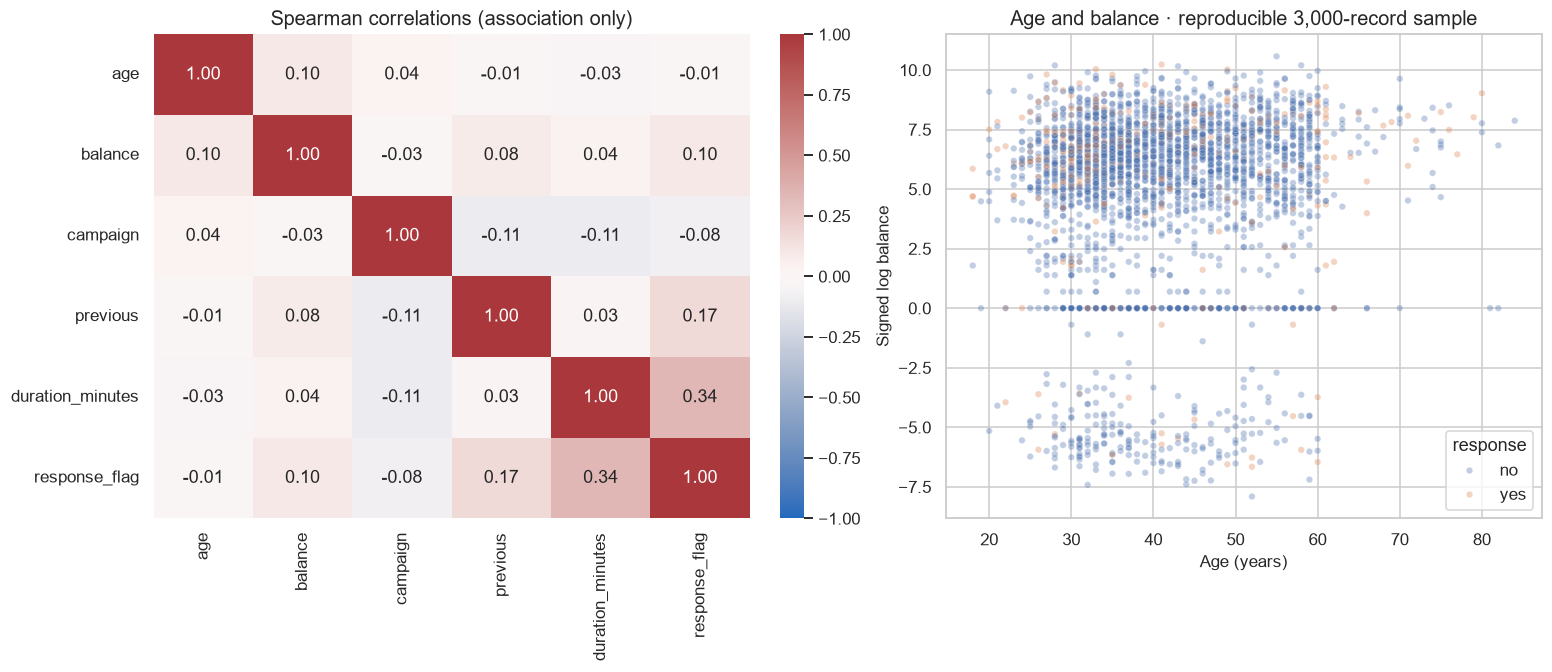

,count,mean,median
response,,,
no,39922,3.686,2.733
yes,5289,8.955,7.100


In [14]:
correlation_cols = ["age", "balance", "campaign", "previous", "duration_minutes", "response_flag"]
correlations = df[correlation_cols].corr(method="spearman")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
sns.heatmap(correlations, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, center=0, ax=axes[0])
axes[0].set_title("Spearman correlations (association only)")
sns.scatterplot(data=df.sample(n=min(3000, len(df)), random_state=SEED),
                x="age", y="signed_log_balance", hue="response", alpha=.35, s=18, ax=axes[1])
axes[1].set(title="Age and balance · reproducible 3,000-record sample", xlabel="Age (years)",
            ylabel="Signed log balance")
plt.show()
display(df.groupby("response", observed=True)["duration_minutes"].agg(["count", "mean", "median"]))

Call duration is related to the response, but it is only known after the call. It should not be used to decide whom to call beforehand. A longer call also does not necessarily cause a subscription.

## 8. Checking outliers

The IQR rule flags values below Q1 - 1.5 × IQR or above Q3 + 1.5 × IQR. These rows stay in the main analysis.

To check how much they matter, compare the overall response rate with and without unusual balances. Also compare previous campaign results within each education group.

In [15]:
outlier_rows = []
for col in ["age", "balance", "duration_minutes", "campaign", "previous"]:
    q1, q3 = np.quantile(df[col], [.25, .75])
    low, high = q1 - 1.5*(q3-q1), q3 + 1.5*(q3-q1)
    mask = ~df[col].between(low, high)
    df[f"{col}_iqr_flag"] = mask
    outlier_rows.append((col, low, high, int(mask.sum()), 100*mask.mean()))
outlier_report = pd.DataFrame(outlier_rows, columns=["field", "lower_fence", "upper_fence", "flagged_n", "flagged_pct"])
display(outlier_report)
duplicate_mask = raw.duplicated().to_numpy()
sensitivity = pd.DataFrame([
    {"scenario": label, "records": len(subset), "rate": subset["response_flag"].mean()}
    for label, subset in [
        ("All records (primary)", df),
        ("Exclude balance IQR flags", df.loc[~df["balance_iqr_flag"]]),
        ("Drop exact duplicate source rows", df.loc[~duplicate_mask]),
    ]
])
sensitivity["difference_pp"] = 100*(sensitivity["rate"]-baseline)
display(sensitivity)
display(Markdown("**Note:** Columns with many zeros can have a very small IQR. "
                 "A flagged value is not necessarily wrong, so these rows are kept."))

stratified_rows = []
for education, subset in df.groupby("education", observed=True):
    success = subset.loc[subset["poutcome"].eq("success"), "response_flag"]
    other = subset.loc[~subset["poutcome"].eq("success"), "response_flag"]
    stratified_rows.append({"education": education, "prior_success_n": len(success),
                           "other_n": len(other), "prior_success_rate": success.mean(),
                           "other_rate": other.mean(), "gap_pp": 100*(success.mean()-other.mean()),
                           "small_comparison": min(len(success), len(other)) < MIN_SEGMENT_N})
stratified = pd.DataFrame(stratified_rows)
display(stratified)

,field,lower_fence,upper_fence,flagged_n,flagged_pct
0,age,10.500,70.500,487,1.077
1,balance,"-1,962.000","3,462.000",4729,10.460
2,duration_minutes,-3.683,10.717,3247,7.182
3,campaign,-2.000,6.000,3064,6.777
4,previous,0.000,0.000,8257,18.263


,scenario,records,rate,difference_pp
0,All records (primary),45211,0.117,0.000
1,Exclude balance IQR flags,40482,0.112,-0.528
2,Drop exact duplicate source rows,45211,0.117,0.000


**Note:** Columns with many zeros can have a very small IQR. A flagged value is not necessarily wrong, so these rows are kept.

,education,prior_success_n,other_n,prior_success_rate,other_rate,gap_pp,small_comparison
0,primary,133,6718,0.609,0.076,53.311,False
1,secondary,675,22527,0.641,0.090,55.194,False
2,tertiary,622,12679,0.658,0.125,53.239,False
3,unknown,81,1776,0.679,0.111,56.809,True


## 9. Main findings

The following points use the results calculated above. Each point includes a possible next step and something to keep in mind when interpreting it.

In [16]:
prior = segments["poutcome"].loc["success"]
prior_share_of_subscriptions = prior["subscriptions"] / df["response_flag"].sum()
one = segments["campaign_band"].loc["1"]
many = segments["campaign_band"].loc["11+"]
unknown_channel = segments["contact"].loc["unknown"]
top_job_name = segments["job"].query("records >= @MIN_SEGMENT_N")["rate"].idxmax()
top_job = segments["job"].loc[top_job_name]
largest_month_name = months["records"].idxmax()
largest_month = months.loc[largest_month_name]
balance_delta = sensitivity.loc[sensitivity["scenario"].eq("Exclude balance IQR flags"), "difference_pp"].iloc[0]

insights = pd.DataFrame([
    {
        "finding": "Previous campaign success stands out",
        "evidence": f"{prior['rate']:.2%} subscribed among {int(prior['records']):,} prior-success records "
                    f"vs {baseline:.2%} overall ({prior['observed_rate_ratio']:.2f}× observed rate ratio).",
        "next_step": "Try a different follow-up approach for eligible customers with previous success and compare it with a control group.",
        "limit": f"Only {prior['record_share']:.1%} of records and {prior_share_of_subscriptions:.1%} of subscriptions; "
                 "this group is too small to be the only focus of the campaign.",
    },
    {
        "finding": "More calls do not always mean more subscriptions",
        "evidence": f"One contact: {one['rate']:.2%} (n={int(one['records']):,}); "
                    f"11+ contacts: {many['rate']:.2%} (n={int(many['records']):,}).",
        "next_step": "Test a limit on follow-up calls and compare subscriptions and contact costs.",
        "limit": "Customers who have not subscribed may be the ones receiving more calls. This does not prove extra calls cause the lower rate.",
    },
    {
        "finding": "Many records have no known contact channel",
        "evidence": f"{int(unknown_channel['records']):,} records ({unknown_channel['record_share']:.1%}) have an unknown channel; "
                    f"their observed rate is {unknown_channel['rate']:.2%}.",
        "next_step": "Record the contact channel more consistently and compare similar campaigns.",
        "limit": "The unknown group is missing information, not a separate marketing channel. Channel rates alone do not prove which channel works better.",
    },
    {
        "finding": "Some smaller job groups have higher response rates",
        "evidence": f"Highest occupation rate with n ≥ {MIN_SEGMENT_N}: {top_job_name}, {top_job['rate']:.2%}, "
                    f"n={int(top_job['records']):,}, {top_job['record_share']:.1%} of records.",
        "next_step": "Look at group sizes along with response rates and check whether the pattern appears in another campaign.",
        "limit": "This ranking is based on the current sample. Job differences do not show cause and effect or justify excluding people.",
    },
    {
        "finding": "The busiest month is not necessarily the highest-response month",
        "evidence": f"{largest_month_name.title()} has the most records: {int(largest_month['records']):,} "
                    f"({largest_month['record_share']:.1%}); its subscription rate is {largest_month['rate']:.2%}.",
        "next_step": "Collect full dates and campaign IDs before deciding to change the campaign schedule.",
        "limit": "There is no year column, and the types of campaigns may differ between months.",
    },
    {
        "finding": "Removing unusual balances changes the result",
        "evidence": f"Excluding balance IQR flags shifts the baseline by {balance_delta:+.2f} percentage points.",
        "next_step": "Keep valid high and low balances, and compare medians alongside means.",
        "limit": "The IQR rule flags unusual values; it does not tell us whether a value is wrong.",
    },
])
for row in insights.itertuples(index=False):
    display(Markdown(f"### {row.finding}\n**Result:** {row.evidence}\n\n"
                     f"**Possible next step:** {row.next_step}\n\n**Keep in mind:** {row.limit}"))

### Previous campaign success stands out
**Result:** 64.73% subscribed among 1,511 prior-success records vs 11.70% overall (5.53× observed rate ratio).

**Possible next step:** Try a different follow-up approach for eligible customers with previous success and compare it with a control group.

**Keep in mind:** Only 3.3% of records and 18.5% of subscriptions; this group is too small to be the only focus of the campaign.

### More calls do not always mean more subscriptions
**Result:** One contact: 14.60% (n=17,544); 11+ contacts: 3.93% (n=1,196).

**Possible next step:** Test a limit on follow-up calls and compare subscriptions and contact costs.

**Keep in mind:** Customers who have not subscribed may be the ones receiving more calls. This does not prove extra calls cause the lower rate.

### Many records have no known contact channel
**Result:** 13,020 records (28.8%) have an unknown channel; their observed rate is 4.07%.

**Possible next step:** Record the contact channel more consistently and compare similar campaigns.

**Keep in mind:** The unknown group is missing information, not a separate marketing channel. Channel rates alone do not prove which channel works better.

### Some smaller job groups have higher response rates
**Result:** Highest occupation rate with n ≥ 100: student, 28.68%, n=938, 2.1% of records.

**Possible next step:** Look at group sizes along with response rates and check whether the pattern appears in another campaign.

**Keep in mind:** This ranking is based on the current sample. Job differences do not show cause and effect or justify excluding people.

### The busiest month is not necessarily the highest-response month
**Result:** May has the most records: 13,766 (30.4%); its subscription rate is 6.72%.

**Possible next step:** Collect full dates and campaign IDs before deciding to change the campaign schedule.

**Keep in mind:** There is no year column, and the types of campaigns may differ between months.

### Removing unusual balances changes the result
**Result:** Excluding balance IQR flags shifts the baseline by -0.53 percentage points.

**Possible next step:** Keep valid high and low balances, and compare medians alongside means.

**Keep in mind:** The IQR rule flags unusual values; it does not tell us whether a value is wrong.

## Conclusion

Previous campaign results are worth looking at when planning follow-ups. The bank could test a different follow-up approach against its existing approach using randomly assigned, eligible customers. It should compare subscriptions per assigned customer and track contact costs over the same period.

For a better follow-up project, the data would need customer IDs, campaign IDs, full dates and costs. These would help separate repeated contacts and compare campaigns more fairly.

### Limitations

- This is an older dataset from one Portuguese bank. The same patterns may not hold for a different bank or a new campaign.
- The analysis shows relationships, not cause and effect. Looking across many groups can also produce patterns by chance.
- Call duration and final contact counts are only fully known after outreach.
- There is no revenue or cost data, so this project cannot calculate profit or claim actual savings.
- No prediction model is trained here; the focus is data cleaning and EDA.

## 10. Final checks and saving results

Check that no rows or subscriptions were lost and that the grouped totals match the full dataset. Set `EXPORT_RESULTS = True` near the top to save the cleaned CSV and summary tables in `bank_marketing_outputs`. Exports are off by default.

In [17]:
assert len(df) == len(raw) == 45211
assert df["response_flag"].sum() == raw["y"].eq("yes").sum()
assert df["duration_minutes"].mul(60).sub(df["duration"]).abs().max() < 1e-9
for name, table in segments.items():
    assert table["records"].sum() == len(df), name
    assert table["subscriptions"].sum() == df["response_flag"].sum(), name
    assert table["rate"].between(0, 1).all(), name
    assert table["ci_low"].le(table["rate"]).all() and table["ci_high"].ge(table["rate"]).all(), name
assert df["days_since_previous_contact"].dropna().ge(0).all()
if EXPORT_RESULTS:
    output = Path("bank_marketing_outputs")
    output.mkdir(exist_ok=True)
    df.to_csv(output / "bank_cleaned.csv", index=False)
    audit.to_csv(output / "cleaning_audit.csv", index=False)
    insights.to_csv(output / "insights_and_actions.csv", index=False)
    sensitivity.to_csv(output / "sensitivity.csv", index=False)
    for name, table in segments.items():
        table.to_csv(output / f"segment_{name}.csv")
    print(f"Exports saved to {output.resolve()}")
print(f"All validation checks passed. {len(df):,} records; {df.response_flag.sum():,} subscriptions; {baseline:.2%} baseline.")

All validation checks passed. 45,211 records; 5,289 subscriptions; 11.70% baseline.
